# MTG - Pokemon, Universe Beyond

In [1]:
# Include and initialization
import hashlib, random
from typing import Dict, List, Optional, Literal
from pydantic import BaseModel
import requests, math
# Allow nested async
import nest_asyncio
import nltk

# For image generation
from diffusers import StableDiffusionPipeline, EulerAncestralDiscreteScheduler
import torch
from PIL import Image, ImageDraw, ImageFont
from compel import Compel

# Identify gpu type (or cpu if none available)
from local_tools import get_device

# Initialize
nest_asyncio.apply()
device = get_device()

# Query shape description for a Pokemon
import requests
import re
import numpy as np
from typing import Optional, Dict, Tuple, List
from PIL import Image, ImageDraw, ImageFont
import math, re, os
from diffusers.models.attention_processor import AttnProcessor2_0


### Define features for general pokemon types and collect features for specific pokemon

In [2]:
# PARAMETERS & Fetchers -- descriptions of Pokemon & MTG card features
POKEAPI = "https://pokeapi.co/api/v2"

# MTG color and rarity types
Rarity = Literal["common","uncommon","rare","mythic"]
Color  = Literal["W","U","B","R","G","C"]

GEN_TO_REGION = {
    "generation-i": "Kanto",
    "generation-ii": "Johto",
    "generation-iii": "Hoenn",
    "generation-iv": "Sinnoh",
    "generation-v": "Unova",
    "generation-vi": "Kalos",
    "generation-vii": "Alola",
    "generation-viii": "Galar",
    "generation-ix": "Paldea",
}

# From "Collect Reference Data" section
MYTHICAL_POKEMON = ['Mew', 'Celebi', 'Jirachi', 'Deoxys', 'Phione', 'Manaphy', 'Darkrai', 'Shaymin', 'Arceus', 
                     'Victini', 'Keldeo', 'Meloetta', 'Genesect', 'Diancie', 'Hoopa', 'Volcanion', 'Magearna', 
                     'Marshadow', 'Zeraora', 'Meltan', 'Melmetal', 'Zarude', 'Pecharunt']

REGION_BG = {
    "kanto":  "Kanto region countryside with rolling hills, cherry trees, and a red wooden bridge",
    "johto":  "Johto shrine forests and terraced villages, stone steps under red maples, calm lake shores",
    "hoenn":  "Hoenn tropical archipelago—basalt cliffs, coral coves, and a distant volcanic peak",
    "sinnoh": "Sinnoh alpine valley—snow-dusted pines, glacial rivers, and ancient stone ruins",
    "unova":  "Unova canal city and farmland—iron bridges, brick rowhouses, and golden autumn fields",
    "kalos":  "Kalos pastoral countryside—lavender rows, limestone walls, and a manor on a distant hill",
    "alola":  "Alola island coast—black-sand beaches, lava rocks, and palm groves in warm trade winds",
    "galar":  "Galar misty moors—stone fences, windmills on ridges, and low clouds over green downs",
    "paldea": "Paldea sunbaked plateaus—olive groves, tiled farmhouses, and ochre cliffs above blue lakes",
}


REGION_STYLE = {
    "kanto":  {"mood":"bright, serene morning",    "palette":"fresh greens, sky blue, soft pink"},
    "johto":  {"mood":"quiet, traditional calm",    "palette":"maple red, moss green, stone gray"},
    "hoenn":  {"mood":"vivid, tropical light",      "palette":"teal sea, coral, sunlit greens"},
    "sinnoh": {"mood":"crisp, northern air",        "palette":"icy blue, pine green, snow white"},
    "unova":  {"mood":"lively, urban-meets-rural",  "palette":"brick red, iron gray, harvest gold"},
    "kalos":  {"mood":"elegant, pastoral charm",    "palette":"lavender, cream limestone, sage"},
    "alola":  {"mood":"warm, breezy island",        "palette":"turquoise, palm green, volcanic black"},
    "galar":  {"mood":"cool, windswept",            "palette":"heather purple, slate, meadow green"},
    "paldea": {"mood":"sunlit, rustic",             "palette":"terracotta, olive, deep blue"},
}

REGION_PALETTES = {
    "kanto": [
        ("#6FCF97", "spring-green"), ("#87CEEB", "sky-blue"),
        ("#F6A6B2", "sakura-pink"), ("#2E6F40", "deep-pine"),
        ("#F3E7C6", "warm-cream"),
    ],
    "johto": [
        ("#C73B3B", "maple-red"), ("#6B8F71", "moss-green"),
        ("#8A8F9A", "stone-gray"), ("#5DA9E9", "lake-blue"),
        ("#F2C14E", "lantern-gold"),
    ],
    "hoenn": [
        ("#2BB7B3", "teal-sea"), ("#FF7F6A", "coral"),
        ("#3C3C47", "basalt"), ("#2F8F5B", "palm-green"),
        ("#FFD166", "sun-yellow"),
    ],
    "sinnoh": [
        ("#A8D0E6", "icy-blue"), ("#F7FAFC", "snow-white"),
        ("#2E5E4E", "pine-green"), ("#556B7A", "slate"),
        ("#7E6BC4", "aurora-violet"),
    ],
    "unova": [
        ("#B5523B", "brick-red"), ("#5A646E", "iron-gray"),
        ("#E0A106", "harvest-gold"), ("#4C9ED9", "canal-blue"),
        ("#7CA982", "field-green"),
    ],
    "kalos": [
        ("#B497C7", "lavender"), ("#EEE3CB", "limestone-cream"),
        ("#97A97C", "sage"), ("#8B3E4D", "wine"),
        ("#8EC5E5", "clear-sky"),
    ],
    "alola": [
        ("#2ECAD5", "turquoise-sea"), ("#2E8B57", "palm-green"),
        ("#1E1E20", "volcanic-black"), ("#FF6B8A", "hibiscus-pink"),
        ("#F3D6A0", "warm-sand"),
    ],
    "galar": [
        ("#7A6C9D", "heather-purple"), ("#5B6770", "slate-gray"),
        ("#6AA84F", "meadow-green"), ("#D0D6DB", "fog-gray"),
        ("#F08A24", "ember-orange"),
    ],
    "paldea": [
        ("#C46A4B", "terracotta"), ("#7A8F28", "olive"),
        ("#2F5DA8", "deep-blue"), ("#E8D4A2", "wheat"),
        ("#C38E26", "sun-ochre"),
    ],
}

# Map PokéAPI shape → plain-English form phrase
SHAPE_PHRASE = {
    "quadruped": "quadrupedal creature",
    "upright": "bipedal creature",
    "legs": "two-legged creature",
    "wings": "winged creature",
    "bug-wings": "insectoid creature with wings",
    "fish": "fish-like creature",
    "tentacles": "tentacled creature",
    "heads": "multi-headed creature",
    "humanoid": "humanoid creature (not human)",
    "ball": "round-bodied creature",
    "blob": "plump round creature",
    "squiggle": "serpentine creature",
    "armor": "armored creature",
    "arms": "armless creature (distinct body with no visible arms)",
}



# Canonical fetchers
def region_bg(region: str) -> str:
    return REGION_BG.get(region.lower(), "a scenic countryside with rolling hills and wildflowers")

def region_mood(region: str) -> str:
    return REGION_STYLE.get(region.lower(), {}).get("mood", "balanced, natural light")

def palette_phrase(region: str, limit: int = 5) -> str:
    chips = REGION_PALETTES.get(region.lower())
    if not chips:
        # Fallback if you *only* had a prose palette earlier:
        prose = REGION_STYLE.get(region.lower(), {}).get("palette")
        return prose or "limited 5-color palette: harmonious mid-saturation colors"
    chips = chips[:limit]
    return "limited {}-color palette: {}".format(
        len(chips), ", ".join([f"{hex} {name}" for hex, name in chips])
    )



In [3]:


# Mood description by MTG color set
MOOD_BY_COLORSET = {
    ("G",): "fresh, lively daylight",
    ("W",): "peaceful, bright morning",
    ("U",): "cool, misty atmosphere",
    ("R",): "dramatic, high-energy lighting",
    ("B",): "mysterious, low-key lighting",
}

In [4]:
# Overrides for known/favorite Pokémon

ICONIC_TYPES = {
    # conservative MTG lines that read clean on a card
    "snorlax": "Legendary Creature — Giant",
    "pikachu": "Legendary Creature — Mouse",
    "gengar":  "Legendary Creature — Spirit",

    # add more overrides as needed; default fallback is "Legendary Creature — Beast"
}

LEGENDARY_DEFAULTS = {
    "pikachu","mewtwo","mew","lugia","ho-oh","rayquaza","snorlax",
    "charizard","blastoise","venusaur","eevee","gengar","greninja",
}

In [55]:
# Query features for pokemon

def _get(url):
    r = requests.get(url, timeout=20)
    r.raise_for_status()
    return r.json()

# Convert size to meters and kg. (PokeAPI gives height in decimeters and weight in hectograms.)
def _meters(decimeters:int) -> float: return round(decimeters / 10.0, 2)
def _kg(hectograms:int) -> float:     return round(hectograms / 10.0, 1)

def _size_class(height_m: float) -> str:
    if height_m < 0.8: return "small"
    if height_m <= 1.5: return "medium"
    return "large"

def _latest_version_group(details):
    """Pick the newest version_group present in the learnset."""
    # crude order: add more as needed
    order = ["red-blue","yellow","gold-silver","crystal","ruby-sapphire","emerald",
             "diamond-pearl","platinum","black-white","black-2-white-2","x-y",
             "omega-ruby-alpha-sapphire","sun-moon","ultra-sun-ultra-moon",
             "sword-shield","scarlet-violet"]
    rank = {k:i for i,k in enumerate(order)}
    best = None; best_rank = -1
    for d in details:
        vg = d.get("version_group",{}).get("name")
        if vg in rank and rank[vg] > best_rank:
            best_rank = rank[vg]; best = vg
    return best

def _choose_key_moves(poke_json, types):
    stabs = {t["type"]["name"] for t in poke_json["types"]}
    # filter level-up moves in the latest version group
    moves = []
    for m in poke_json["moves"]:
        md = [d for d in m["version_group_details"] if d["move_learn_method"]["name"] == "level-up"]
        if not md: continue
        vg = _latest_version_group(md)
        if not vg: continue
        moves.append(m["move"]["name"])

    # rank by: STAB > known/iconic names > power (requires per-move fetch)
    ranked = []
    for mv in moves[:40]:  # cap network calls
        try:
            mj = _get(f"{POKEAPI}/move/{mv}")
            power = mj.get("power") or 0
            mtype = mj["type"]["name"]
            stab = 1 if mtype in stabs else 0
            iconic = 1 if mv in {"tackle","quick-attack","yawn","thunderbolt","shadow-ball","water-gun"} else 0
            ranked.append((stab, iconic, power, mj["name"]))
        except Exception:
            continue
    ranked.sort(reverse=True)
    out = [mv for _,_,_,mv in ranked[:3]]
    # Title-case nicely
    return [s.replace("-", " ").title() for s in out] or ["Tackle"]

def fetch_pokemon_features(name: str):
    nid = name.strip().lower()
    p = _get(f"{POKEAPI}/pokemon/{nid}")
    s = _get(f"{POKEAPI}/pokemon-species/{nid}")

    types = [t["type"]["name"].title() for t in sorted(p["types"], key=lambda x: x["slot"])]
    height_m = _meters(p["height"])
    weight_kg = _kg(p["weight"])
    size = _size_class(height_m)
    region = GEN_TO_REGION.get(s["generation"]["name"], "Unknown")

    shape = (s.get("shape") or {}).get("name")          # e.g., 'quadruped', 'fish', 'upright', ...
    color = (s.get("color") or {}).get("name")          # e.g., 'pink', 'blue', ...
    genus = next((g["genus"] for g in s.get("genera", [])
                  if g["language"]["name"] == "en"), "")
    genus = genus.replace("Pokémon", "").strip().lower()
    isNoun = lambda pos: pos[:2] == 'NN'
    tokenized = nltk.word_tokenize(genus)
    genus = [word for (word, pos) in nltk.pos_tag(tokenized) if isNoun (pos) and pos.lower() not in ['evolution', 'tiny']]
    if genus:
        genus = genus[0]
    else:
        genus = ""

    flavor_en = " ".join(ft["flavor_text"].replace("\n", " ").replace("\f", " ")
                         for ft in s.get("flavor_text_entries", [])
                         if ft["language"]["name"] == "en")


    # Top-listed ability is fine; you can prefer non-hidden
    abilities = [a["ability"]["name"].replace("-", " ").title() for a in p["abilities"]]
    if abilities:
        # prefer non-hidden first
        abilities.sort(key=lambda a: 1 if "Hidden" in a else 0)

    key_moves = _choose_key_moves(p, types)

    return {
        "name": name.title(),
        "region": region,
        "types": types,                # e.g., ["Water","Psychic"]
        "size": size,                  # small / medium / large
        "height_m": height_m,
        "weight_kg": weight_kg,
        "shape": shape,                # e.g., 'quadruped', 'fish', 'upright', ...
        "color": color,                # e.g., 'pink', 'blue', ...
        "genus": genus,                # e.g., 'Seed Pokémon'
        "flavor_text": flavor_en,      # concatenated English flavor text entries
        "is_legendary": s.get("is_legendary", False) or s.get("is_mythical", False) or (name.lower() in LEGENDARY_DEFAULTS),
        "is_mythical": s.get("is_mythical", False),
        "key_moves": key_moves,        # 2–3 iconic/typed moves
        "ability": abilities[0] if abilities else None,
        "sources": {
            "pokemon": f"{POKEAPI}/pokemon/{nid}",
            "species": f"{POKEAPI}/pokemon-species/{nid}"
        }
    }


In [56]:
from pydantic import BaseModel
from langchain_core.tools import tool

class PokemonArgs(BaseModel):
    pokemon_name: str

@tool("web_pokemon_features", args_schema=PokemonArgs)
def web_pokemon_features_tool(pokemon_name: str) -> dict:
    "Return Region, Types, Size, Key moves (+ ability/height/weight) for a Pokémon."
    return fetch_pokemon_features(pokemon_name)



### Define Pokemon artwork
Convert Pokemon features into text descriptions and use them for a Static Diffusion prompt

In [57]:



# Simple size → adjective
SIZE_ADJ = {"small":"small", "medium":"medium-sized", "large":"large"}

# Make the stored color more descriptive
def color_adj(c):
    if not c: return None
    return {
        "pink": "soft pink",
        "red": "deep red",
        "blue": "sky blue",
        "yellow": "warm yellow",
        "green": "leafy green",
        "brown": "earthy brown",
        "black": "charcoal black",
        "white": "soft white",
        "purple": "violet",
        "gray": "ash gray",
    }.get(c.lower(), c)

# Trait mining from flavor text (very light, avoids noise)
TRAIT_LEX = {
    r"\bwings?\b": "wings",
    r"\bfin[s]?\b": "fins",
    r"\b(horn|antler)s?\b": "horns",
    r"\b(claw|talon)s?\b": "claws",
    r"\b(spike|spine)s?\b": "spikes",
    r"\bshell\b": "shell",
    r"\btail\b": "long tail",
    r"\bbelly\b": "round belly",
    r"\bsleep|drows|lazy\b": "sleepy demeanor",
}

def mine_traits(flavor: str, limit=2):
    found = []
    text = flavor.lower()
    for pat, tag in TRAIT_LEX.items():
        if re.search(pat, text):
            found.append(tag)
        if len(found) >= limit:
            break
    return found

def subject_blueprint(feat: dict) -> str:
    name  = feat["name"]
    size  = SIZE_ADJ.get(feat.get("size","medium"), "medium-sized")
    shape = SHAPE_PHRASE.get(feat.get("shape","") or "", None) or "creature"
    cword = color_adj(feat.get("color"))
    traits = mine_traits(feat.get("flavor_text",""))
    traits_phrase = (", ".join(traits) + ", ") if traits else ""
    color_phrase  = f"{cword} " if cword else ""
    # blueprint keeps it factual and short; we’ll add composition elsewhere
    return f"{name}, {size} {color_phrase}{shape} with {traits_phrase}clear facial features and a distinct silhouette"

# Display water type pokemon near some pool of water
def water_anchor(feat: dict) -> str | None:
    types = {t.lower() for t in feat.get("types", [])}
    shape = (feat.get("shape") or "").lower()
    name  = feat["name"].lower()
    if "water" in types or shape in {"fish","squiggle"} or name in {"slowpoke","gyarados","magikarp"}:
        return "standing beside a calm blue river or tide pool; water clearly visible in the lower third of the frame"
    return None

# α in [0,1]: 0 = more Pokémon-ish, 1 = more MTG-ish
def style_mix(mtg_base_style: List[str], poke_base_style: List[str], alpha: float, gain: float = 0.6) -> str:

    # weight both sides explicitly (inline Compel weights)
    w_poke = 1.0 + (1.0 - alpha) * gain
    w_mtg  = 1.0 + alpha * gain

    poke = ", ".join(f"({b}:{w_poke:.2f})" for b in poke_base_style)
    mtg  = ", ".join(f"({b}:{w_mtg:.2f})"  for b in mtg_base_style)
    return f"{poke}, {mtg}"






### Define MTG Card features
"MTG-ify" the defined Pokemon features. This defines the card text as well as inform symbol selection for the card generation

In [58]:
# Feature translation from Pokémon to MTG

# Pokémon types to MTG colors
TYPE_TO_COLORS = {
    "grass": ["G"], "fire": ["R"], "water": ["U"], "electric": ["U","R"],
    "psychic": ["U","B"], "fighting": ["R","G"], "fairy": ["W"],
    "dark": ["B"], "ghost": ["U","B"], "steel": ["W","C"],
    "dragon": ["G","R","U"], "normal": ["W","G"], "ice": ["U","W"],
    "rock": ["R","W"], "ground": ["G","W"], "bug": ["G"], "poison": ["B","G"],
}

# Pokémon types to MTG subtypes
TYPE_TO_MTG_SUBTYPE = {
    "ghost": "Spirit",
    "dragon": "Dragon",
    "fairy": "Faerie",
    "bug": "Insect",
    "steel": "Construct",
    "rock": "Elemental",
    "ice": "Elemental",
    "fire": "Elemental",
    "water": "Elemental",
    "electric": "Elemental",
    "grass": "Plant Beast",
    "poison": "Horror",
    "psychic": "Horror",
    "dark": "Horror",
    "fighting": "Warrior",
    "ground": "Beast",
    "normal": "Beast",
}


# --- color/size → stats & keywords ---
def pokemon_types_to_colors(types: List[str]) -> List[str]:
    t1 = (types[0] if types else "normal").lower()
    c = TYPE_TO_COLORS.get(t1, ["W"])
    if len(types) > 1:
        t2 = types[1].lower()
        c2 = TYPE_TO_COLORS.get(t2, c)
        c = sorted(list({c[0], c2[0]}))[:2]
    return c



In [59]:
# Develop general spec for cards and artwork

# ArtSpec and CardSpec are used to define the structure of the card and its artwork.
class ArtSpec(BaseModel):
    style: Literal["painterly","watercolor","clay","vector"] = "painterly"
    scene: str
    focal_points: List[str] = []
    composition: Literal["center","three_quarters_left","three_quarters_right","dynamic"] = "center"
    mood: str = "bright, adventurous"
    seed: Optional[int] = None

class CardSpec(BaseModel):
    ip_universe: Literal["Pokemon x MTG (Universes Beyond)"] = "Pokemon x MTG (Universes Beyond)"
    name: str
    mana_cost: str           # like "{2}{G}{U}"
    type_line: str      # like "Creature — Beast"
    rarity: str              # "C","U","R","M"
    oracle_text: str    # with {G} etc allowed
    keywords: List[str] = None
    power: Optional[str] = None
    toughness: Optional[str] = None
    loyalty: Optional[int] = None
    flavor_text: Optional[str] = None
    set_code: str = "UBPK"
    collector_no: Optional[str] = None
    color: List[str] = []               # "W","U","B","R","G" (use first color for frame)
    art: ArtSpec
    artist: Optional[str] = "Daly"



In [60]:
# Detailed specs for MTG cards based on known features.

def seeded_int(s: str) -> int:
    return int(hashlib.sha256(s.encode()).hexdigest()[:8], 16) & 0x7FFFFFFF

# Pick MTG rarity with overrides for known Pokémon
def pick_rarity(name: str, target: Optional[str]) -> str:
    if target: return target
    if name.lower() in LEGENDARY_DEFAULTS:
        return "rare"
    # deterministic weighted pick
    r = seeded_int("rarity:"+name) % 100
    return "mythic" if r < 5 else ("rare" if r < 40 else ("uncommon" if r < 85 else "common"))

# Mana cost by colors + size + rarity
def mana_cost_for(colors: List[str], rarity: str, size_hint: str, name_seed: int) -> str:
    # rough CMC by size + rarity
    base = {"small": 2, "medium": 3, "large": 5}[size_hint]
    bump = {"common": 0, "uncommon": 0, "rare": 1, "mythic": 1}[rarity]
    cmc = max(1, base + bump)
    # build like {2}{G}{G} or {1}{U}{B}
    pips = colors[:2]
    # distribute generic with a little randomness
    generic = max(0, cmc - len(pips))
    return "".join([f"{{{generic}}}" if generic else ""] + [f"{{{c}}}" for c in pips])

# Define power, toughness, and keywords by colors + size
def size_to_stats(size: str, colors: List[str]) -> tuple[str,str]:
    # small / medium / large → P/T bands, with W/G toughness buff
    if size == "small":
        p,t = 2,1
    elif size == "large":
        p,t = 4,5
    else:
        p,t = 3,3
    if "W" in colors: t += 1
    if "G" in colors and size != "small": t += 1
    return str(p), str(t)

def evergreen_keywords_for_colors(colors: List[str]) -> List[str]:
    kws = []
    if "W" in colors: kws.append("Vigilance")
    if "U" in colors: kws.append("Flying")
    if "B" in colors: kws.append("Deathtouch")
    if "R" in colors: kws.append("Haste")
    if "G" in colors: kws.append("Trample")
    return kws

# Translate move types into an MTG action.
MOVE_TEMPLATES = {
    'air slash': '{1}{U}: this creature gains flying until end of turn.',
    'aqua tail': "{1}{G}: Target creature you control fights up to one target creature you don't control.",
    'bite': "Whenever this creature attacks, target creature an opponent controls can't block this turn.",
    'blizzard': "{4}{U}: Tap all creatures target player controls. Those creatures don't untap during that player's next untap step. Activate only as a sorcery.",
    'body slam': 'Whenever this creature attacks, it gets +1/+1 and gains trample until end of turn.',
    'bulk up': '{1}{G}: Put a +1/+1 counter on this creature. It gains trample until end of turn.',
    'close combat': 'Whenever this creature attacks, it gets +2/+2 until end of turn. At end of combat, sacrifice it unless you pay {1}.',
    'dragon claw': "{1}{G}: this creature fights target creature you don't control.",
    'dragon dance': '{1}{R}: Put a +1/+1 counter on this creature. It gains haste until end of turn.',
    'earthquake': '{X}{R}: this creature deals X damage to each creature without flying. Activate only as a sorcery.',
    'fire spin': "{1}{R}: Target creature can't block this turn.",
    'flamethrower': '{2}{R}: this creature deals 3 damage to target creature.',
    'flare blitz': 'Whenever this creature attacks, it gets +3/+0 until end of turn. At end of combat, this creature deals 2 damage to you.',
    'future sight': '{U}: Scry 2.',
    'giga drain': 'Whenever this creature deals combat damage to a player, you gain that much life.',
    'heat wave': "{2}{R}: Heat Wave deals 1 damage to each creature you don't control.",
    'hydro pump': "{2}{U}: Return target creature to its owner's hand, scry 1.",
    'hypnosis': "When this creature enters, tap target creature an opponent controls. It doesn't untap during its controller's next untap step.",
    'ice beam': "When this creature enters, tap up to one target creature. It doesn't untap during its controller's next untap step.",
    'inferno': '{3}{R}: Inferno deals 2 damage to each creature. Activate only as a sorcery.',
    'knock off': 'Whenever this creature deals combat damage to a player, that player discards a card.',
    'leech seed': 'Whenever this creature deals combat damage to a creature, put a -1/-1 counter on that creature and you gain 1 life.',
    'moonblast': '{2}{W}: Exile target attacking creature with power 4 or greater.',
    'overheat': "{3}{R}: Overheat deals 4 damage to target creature or planeswalker. this creature doesn't untap during your next untap step.",
    'quick attack': "This creature has first strike as long as it's attacking.",
    'razor leaf': '{G}: this creature gets +1/+1 and gains reach until end of turn.',
    'rock slide': '{2}{R}: this creature deals 1 damage to each creature your opponents control.',
    'sandstorm': '{1}{W}: Prevent all combat damage that would be dealt this turn by creatures without flying.',
    'shadow ball': 'Whenever this creature deals combat damage to a player, that player mills three cards.',
    'sleep powder': "{1}{G/U}: Tap target creature. It doesn't untap during its controller's next untap step.",
    'sludge bomb': '{2}{B}: Target creature gets -3/-3 until end of turn.',
    'surf': "When this creature enters the battlefield, tap up to two target creatures you don't control. Those creatures don't untap during their controller's next untap step.",
    'tailwind': '{2}{W}: Creatures you control get +1/+0 and gain vigilance until end of turn.',
    'taunt': '{R}: Goad target creature.',
    'teleport': "{1}{U}: Exile this creature, then return it to the battlefield tapped under its owner's control.",
    'thunder wave': "{U}: Tap target creature. It doesn't untap during its controller's next untap step.",
    'thunderbolt': 'Whenever you cast a noncreature spell, this creature deals 1 damage to any target.',
    'toxic': 'Whenever this creature deals combat damage to a player, that player gets a poison counter.',
    'vine whip': 'Whenever this creature attacks, put a +1/+1 counter on up to one target creature you control.',
    'volt switch': "{1}{U/R}: Return this creature to its owner's hand. When it leaves the battlefield this way, it deals 1 damage to any target.",
    'water gun': 'When this creature enters, scry 2.',
    'waterfall': "{2}{U}: Tap up to two target creatures. They don't untap during their controller's next untap step.",
    'will-o-wisp': '{1}{B}: Target creature gets -1/-1 until end of turn.',
    'yawn': "When this creature enters, tap up to one target creature. It doesn't untap during its controller's next untap step."
    }



def moves_to_oracle_lines(key_moves: List[str], colors: List[str], archetype: str) -> List[str]:
    lines = []
    # prefer mapped moves first
    for mv in key_moves:
        key = mv.lower().replace("-", " ")
        if key in MOVE_TEMPLATES:
            moveName = ' '.join(w.capitalize() for w in key.split(' '))
            lines.append(moveName + ":"+MOVE_TEMPLATES[key])
        if len(lines) >= 2:
            break
    # ensure at least one line keyed to color identity
    if not lines:
        if "U" in colors:
            lines.append("When this creature enters, scry 2.")
        elif "G" in colors:
            lines.append("When this creature enters, put a +1/+1 counter on up to one other target creature you control.")
        elif "R" in colors:
            lines.append("Whenever this creature attacks, it deals 1 damage to any target.")
        elif "B" in colors:
            lines.append("Whenever another creature dies, you gain 1 life.")
        else:  # W
            lines.append("Whenever you gain life, put a +1/+1 counter on this creature.")
    # one static line keyed to archetype
    if archetype == "large":
        lines.append("Ward {2}")
    elif archetype == "small":
        lines.append("Prowess")
    else:
        lines.append("Reach" if "G" in colors else "First strike" if "R" in colors else "Hexproof from instants" if "U" in colors else "Menace" if "B" in colors else "Lifelink")

    return lines[:4]



In [61]:
# Build flavor text from long description in API
import re, random

MAX_WORDS = 16

BAD_TOKENS = {"pokémon","pokedex","trainer","professor","researcher","kilogram","pound","lbs","kg"}
CLAUSE_SPLIT = re.compile(r"\s*(?:,|;|\sbut\s|\sand\s|\swhich\s|\sthat\s|\swhen\s|\sif\s)\s+", re.I)
SENT_SPLIT = re.compile(r"(?<=[.!?])\s+")
WS = re.compile(r"\s+")

def _normalize_ft(text: str) -> str:
    t = text.replace("\f","\n").replace("\r","\n")
    t = WS.sub(" ", t).strip()
    return t

def _sentences(t: str) -> list[str]:
    # Keep punctuation as sentence boundary, then strip
    out = [s.strip(" \t\"'") for s in SENT_SPLIT.split(t)]
    # filter empties and duplicates
    seen, keep = set(), []
    for s in out:
        if not s: continue
        if s.lower() in seen: continue
        seen.add(s.lower()); keep.append(s)
    return keep

def _word_count(s: str) -> int:
    return len(s.split())

def _sanitize_entities(s: str, name: str) -> str:
    s = re.sub(r"\b[Pp]ok[eé]mon\b", "creature", s)
    s = re.sub(fr"\b{re.escape(name)}\b", "it", s, flags=re.I)
    return s

def _strip_modernisms(s: str) -> str:
    # nuke modern nouns/units if they show up
    parts = [w for w in s.split() if w.lower().strip(".,;:") not in BAD_TOKENS]
    return " ".join(parts)

def _first_good_clause(s: str) -> str:
    # take the first meaningful clause before we hit a connective
    return CLAUSE_SPLIT.split(s)[0]

def _score_sentence(s: str, types: set[str]) -> float:
    n = _word_count(s)
    if n < 5 or n > MAX_WORDS + 6: return -1e9
    score = 100.0
    score -= abs(n - 11) * 2.0                       # prefer ~11 words
    if re.search(r"\d", s): score -= 12              # penalize numbers
    if any(tok in s.lower() for tok in BAD_TOKENS): score -= 12
    # small bonus if it echoes the type
    if "water" in types and re.search(r"\b(river|shore|tide|water|current)\b", s, re.I): score += 6
    if "fire"  in types and re.search(r"\b(fire|ember|smoke|ash|flame)\b", s, re.I):    score += 6
    if "psychic" in types and re.search(r"\b(mind|dream|thought|memory)\b", s, re.I):   score += 6
    return score

def compress_flavor_from_pokedex(raw_text: str, name: str, types: list[str]) -> str | None:
    t = _normalize_ft(raw_text)
    cands = []
    for s in _sentences(t):
        s0 = _first_good_clause(s)                  # trim after comma/but/which…
        s1 = _sanitize_entities(s0, name)
        s2 = _strip_modernisms(s1)
        # hard cap without ellipsis (MTG style prefers complete thought)
        words = s2.split()
        if len(words) > MAX_WORDS:
            s2 = " ".join(words[:MAX_WORDS])
        cands.append(s2.strip(" .") + ".")
    # score & pick
    T = {t.lower() for t in types}
    cands = sorted(set(cands), key=lambda s: -_score_sentence(s, T))
    return cands[0] if cands and _score_sentence(cands[0], T) > -1e8 else None

# Fallback you already liked (tiny MTG-ish generator)
def make_flavor_text_fallback(features: dict) -> str:
    name   = features.get("name","").title()
    types  = {t.lower() for t in features.get("types",[])}
    shape  = (features.get("shape") or "creature").replace("-", " ")
    opts = [
        "Its calm is a tide; its memory, an eddy.",
        "Where it rests, time pools like water.",
        "Only the current remembers what it was.",
        f"A {shape} with patient eyes and a weightless mind.",
    ]
    if "water" in types: opts += ["It lingers by the shore, forgetting the world."]
    return random.choice(opts)

def ensure_flavor_text_from_api(spec, features):
    raw = (features.get("flavor_text") or "").strip()
    if raw:
        picked = compress_flavor_from_pokedex(raw, features.get("name",""), features.get("types",[]))
        if picked: 
            spec.flavor_text = picked
            return spec
    # fallback
    spec.flavor_text = make_flavor_text_fallback(features)
    return spec


In [62]:
# Develop card and art specs

def build_art_spec_from_features(features: dict) -> ArtSpec:
    name   = features["name"].title()
    region = features.get("region", "kanto")
    types  = features.get("types", [])
    colors = pokemon_types_to_colors(types)
    seed   = seeded_int(f"art:{name}:{region}")
    # composition variety but deterministic
    comps = ["center","three_quarters_left","three_quarters_right","dynamic"]
    comp  = comps[seed % len(comps)]

    scene = f"{name}, a heroic depiction of a {name} Pokemon {water_anchor(features)} in the {region_bg(region)}"
    mood  = region_mood(region)
    style = "painterly"  # house style for MTG-ified art

    return ArtSpec(
        style=style,
        scene=scene,
        focal_points=[f"{name} is the clear focal subject"],
        composition=comp,
        mood=mood,
        seed=seed,
    )

def build_card_spec_from_features(features: dict, *, target_rarity: Optional[str]=None) -> CardSpec:
    name   = features["name"].title()
    types  = [t.title() for t in features.get("types", [])]
    region = features.get("region", "kanto")
    size   = features.get("size", "medium")
    key_moves = features.get("key_moves", [])
    ability   = (features.get("ability") or "").title()
    genus   = (features.get("genus") or "").title()

    colors = pokemon_types_to_colors(types)
    # rarity: famous mascots skew rare; else deterministic pick
    if target_rarity:
        rarity = target_rarity
    elif name.lower() in LEGENDARY_DEFAULTS:
        rarity = "rare"
    else:
        r = seeded_int("rarity:"+name) % 100
        rarity = "mythic" if r < 5 else ("rare" if r < 40 else ("uncommon" if r < 85 else "common"))

    # stats/keywords/mana
    power, toughness = size_to_stats(size, colors)
    keywords = evergreen_keywords_for_colors(colors)
    mana_cost = mana_cost_for(colors, rarity, size, seeded_int(name))

    # type line
    primary_type = (types[0] if types else "Normal").lower()
    subtype = TYPE_TO_MTG_SUBTYPE.get(primary_type, "Beast")
    if (subtype == "Elemental" or subtype == "Beast") and genus != "":
        subtype = genus
    is_legendary = (name.lower() in LEGENDARY_DEFAULTS) or rarity == "mythic"
    type_line = f"{'Legendary ' if is_legendary else ''}Creature — {subtype}"

    # oracle
    oracle_lines = [x.replace("this creature", name).replace("This creature",name) for x in moves_to_oracle_lines(key_moves, colors, size)]
    # small ability nudge (very light; avoid bloat)
    if ability and "Thick Fat" in ability and "Ward" not in keywords:
        oracle_lines.append("Ward {2}")
    oracle_text = "\n".join(oracle_lines)

    # flavor (optional)
    flavor = None

    # art
    art = build_art_spec_from_features(features)

    baseSpec = CardSpec(
        name=name,
        mana_cost=mana_cost,
        color=colors,
        type_line=type_line,
        rarity=rarity,
        oracle_text=oracle_text,
        keywords=keywords,
        power=power, toughness=toughness,
        flavor_text=flavor,
        art=art,
        artist="Daly",
        collector_no=f"{np.random.randint(1,151)} / 151"
    )
    return ensure_flavor_text_from_api(baseSpec, features)

def features_to_specs(features: dict, *, target_rarity: Optional[str]=None) -> CardSpec:
    """Convenience: returns a CardSpec with ArtSpec filled in."""
    return build_card_spec_from_features(features, target_rarity=target_rarity)

In [63]:
# BUILD SD PROMPT from CardSpec

# Color-identity mixins (very light touch; keeps the “MTG vibe”)
COLOR_MIXINS = {
    "W": "linen, heraldry, carved stone, doves, serene order",
    "U": "mist, ripples, cool highlights, subtle glimmer, quiet focus",
    "B": "deep shadows, tarnished iron, worn bone, low-key lighting",
    "R": "heat-scorched leather, forged iron, ember glow, sparks",
    "G": "vines, moss, roots, bark textures, dappled canopy light",
}

# Style-specific tuning (you can expand later)
STYLE_TUNING = {
    "painterly": dict(num_inference_steps=48, guidance_scale=7.2, width=768, height=512,
                      base="painterly brushwork, cinematic rim lighting, rich but natural color, "
                           "clean subject separation, soft background bokeh"),
    "watercolor": dict(num_inference_steps=24, guidance_scale=6.6, width=768, height=512,
                       base="children’s book watercolor, soft washes, paper grain, gentle edges"),
    "clay": dict(num_inference_steps=32, guidance_scale=7.8, width=768, height=512,
                 base="3D claymation look, soft clay material, studio softbox lighting, subtle depth of field"),
    "vector": dict(num_inference_steps=24, guidance_scale=6.5, width=768, height=512,
                   base="flat vector illustration, minimal shading, crisp shapes, bold outline"),
}

NEGATIVE_MTG = (
    "empty landscape, distant subject, tiny subject, out of frame, card frame, border, text, captions, watermarks, logos, symbols, template,"
    "numbers, stats, cropped edges, trading card, design layout,"
    "blur, text, watermark, mutated, extra limbs, poorly drawn, missing ear,"
    "anime, chibi, cartoon, toy plastic, glossy plastic, cel shading, flat lighting, "
    "nsfw, sexual, gore, dismemberment, watermark, caption, letters, numbers, logo, pokeball, modern tech, text,"
)

def _comp_phrase(kind: str) -> str:
    return {
        "center": "centered three-quarter view",
        "three_quarters_left": "subject framed slightly left with leading space",
        "three_quarters_right": "subject framed slightly right with leading space",
        "dynamic": "dynamic diagonal composition, rule of thirds",
    }.get(kind, "centered three-quarter view")

def _join_parts(parts: List[str]) -> str:
    return ", ".join([p.strip().strip(",") for p in parts if p and p.strip()])


def build_pokemon_prompt(features: dict, card: CardSpec, compel: Compel, alpha=0.65,
                         include_palette: bool = True) -> Dict:
    blueprint = subject_blueprint(features)
    presence  = "solo, one creature, front and center, full body visible, occupies ~60% of the frame, sharp focus on subject"
    env       = REGION_BG[features.get("region", "kanto").lower()]
    water     = water_anchor(features)
    poke_base_style = ["rounded forms", "smooth matte surface", "simplified anatomy", "clear facial features"]
    mtg_base_style = card.art.style or "painterly"
    tune = STYLE_TUNING.get(mtg_base_style, STYLE_TUNING["painterly"])
    style     = style_mix(mtg_base_style, poke_base_style, alpha)
    colors = set(card.color or [])
    color_bits = [COLOR_MIXINS[c] for c in ["W","U","B","R","G"] if c in colors]

    parts = [
        blueprint,                         # ← morphology from API
        presence,
        f"{env}",
        water or "",
        _join_parts(color_bits) if color_bits else None,
        style,
        "soft rim light, clean subject separation, shallow depth of field",
        "SUBJECT uses its natural color; BACKGROUND uses greens and browns; WATER is blue"
    ]
    prompt = ", ".join([p for p in parts if p])

    negative = (
        "empty landscape, distant subject, tiny subject, out of frame, cropped head, back view, "
        "silhouette only, camouflage, monochrome color cast, pink foliage, blur, text, watermark, logo, "
        "animal photograph, taxidermy, photorealistic, ultra-realistic, skin pores, hyper-detailed microtexture, "
        "anime, chibi, cel shading, toy, glossy plastic"
    )
    # color-guard: if the species color is pink/blue/etc, block that color in the foliage
    col = (features.get("color") or "").lower()
    if col in {"pink","purple","red"}:
        negative += ", pink foliage, purple foliage, red foliage"

    if include_palette:
        prompt += f", {palette_phrase(env)}, subject uses first two swatches, background uses last two"
    prompt_embeds = compel.build_conditioning_tensor(f"({card.name}: 1.6), {prompt}").to(device)
    neg_prompt_embeds = compel.build_conditioning_tensor(NEGATIVE_MTG).to(device)
    # seed: prefer ArtSpec.seed; else derive from name + region
    seed = card.art.seed if getattr(card.art, "seed", None) is not None else seeded_int(f"art:{card.name}:{env}")

    return {
        "prompt_embeds": prompt_embeds,
        "negative_prompt_embeds": neg_prompt_embeds,
        "width": tune["width"],
        "height": tune["height"],
        "num_inference_steps": tune["num_inference_steps"],
        "guidance_scale": tune["guidance_scale"],
        "seed": int(seed),
    }
    

### Card Renderer
Builds the frame and populates it with the descriptive text, icons and the image

In [64]:

# ---------- Config ----------
W,H   = 744, 1038          # 2.5" x 3.5" @ ~300dpi
MARG  = 36                 # outer margin
ART_H = 500                # art window height
SCALE = 2                  # supersample for nicer text/curves

# Color themes per MTG color (frame, bar, text)
THEME = {
    "W": {"frame":"#e8e2d8","bar":"#cdc5b4","rulebox":"#efe9df","text":"#1b1b1b","accent":"#9a8f7b"},
    "U": {"frame":"#b9d7f0","bar":"#88b9dc","rulebox":"#d7e9f7","text":"#0b2239","accent":"#3e6fa1"},
    "B": {"frame":"#b9b2b3","bar":"#8c8788","rulebox":"#d7d2d3","text":"#0e0d0d","accent":"#504b4c"},
    "R": {"frame":"#f1c0b6","bar":"#d88774","rulebox":"#f6ddd7","text":"#3a0e0b","accent":"#a44b3d"},
    "G": {"frame":"#cfe0c6","bar":"#9cc18e","rulebox":"#e6efe1","text":"#102014","accent":"#5f8a56"},
}



# Basic fonts (drop nicer TTFs if you have them)
def _try_font(paths: List[str], size:int):
    for p in paths:
        if os.path.exists(p):
            try: return ImageFont.truetype(p, size)
            except: pass
    return ImageFont.load_default()

# Try common MTG-ish fonts first if you have them
BELEREN = _try_font([
    "/Library/Fonts/Beleren-Bold.ttf",
    "/Library/Fonts/BelerenSmallCaps-Bold.ttf",
    "/System/Library/Fonts/Supplemental/Georgia Bold.ttf",
    "/System/Library/Fonts/Supplemental/Times New Roman Bold.ttf",
], 26*SCALE)

BODY    = _try_font([
    "/Library/Fonts/Plantin.ttf",
    "/System/Library/Fonts/Supplemental/Times New Roman.ttf",
    "/System/Library/Fonts/Supplemental/Georgia.ttf",
], 22*SCALE)

ITALIC  = _try_font([
    "/Library/Fonts/Plantin-Italic.ttf",
    "/System/Library/Fonts/Supplemental/Times New Roman Italic.ttf",
    "/System/Library/Fonts/Supplemental/Georgia Italic.ttf",
], 21*SCALE)

SMALL   = _try_font([
    "/System/Library/Fonts/Supplemental/Arial.ttf",
], 18*SCALE)

def _hex_rgba(h, a=255):
    h = h.lstrip("#")
    r = int(h[0:2], 16); g = int(h[2:4], 16); b = int(h[4:6], 16)
    return (r, g, b, a)

def make_linear_gradient(size, c_top, c_bot, vertical=True):
    w, h = size
    base = Image.new("RGBA", size, c_top)
    grad = Image.new("L", (1, h if vertical else w))
    for i in range(grad.height if vertical else grad.width):
        t = i / max(1, (grad.height if vertical else grad.width) - 1)
        grad.putpixel((0 if vertical else i, i if vertical else 0), int(255*t))
    grad = grad.resize(size)
    overlay = Image.new("RGBA", size, c_bot)
    return Image.composite(overlay, base, grad)

def make_diagonal_stripes(size, bg, fg, spacing=16, thickness=2, opacity=30):
    w, h = size
    img = Image.new("RGBA", size, bg)
    d = ImageDraw.Draw(img)
    col = _hex_rgba(fg, int(255 * (opacity/100)))
    # draw / diagonals
    for x in range(-h, w, spacing):
        d.line([(x, 0), (x + h, h)], fill=col, width=thickness)
    return img

def make_linen_paper(size, base_hex, tint_hex=None, noise_sigma=24, grain_opacity=22):
    """Subtle paper/linen texture: base color + light noise + gentle vertical gradient."""
    w, h = size
    base = Image.new("RGBA", size, base_hex)
    # noise layer (grayscale)
    noise = Image.effect_noise((w, h), noise_sigma).convert("L")       # Pillow’s builtin noise
    alpha = noise.point(lambda v: int(v * (grain_opacity/255.0)))      # very low opacity
    grain = Image.new("RGBA", size, (0, 0, 0, 0))
    grain.putalpha(alpha)
    paper = Image.alpha_composite(base, grain)

    # gentle vertical gradient shading to add depth
    top = _hex_rgba(base_hex, 255)
    bot = _hex_rgba(base_hex, 255)
    # nudge top/bottom brightness slightly via tint if provided
    if tint_hex:
        tint = Image.new("RGBA", size, _hex_rgba(tint_hex, 28))  # low alpha
        paper = Image.alpha_composite(paper, tint)
    grad = make_linear_gradient(size, (0,0,0,0), (0,0,0,30), vertical=True)
    paper = Image.alpha_composite(paper, grad)
    return paper


In [65]:
# ---------- Drawing helpers ----------
def _rarity_color(r: str) -> tuple[str, str]:
    r = (r or "").upper()
    # fill, outline
    return {
        "C": ("#5a5a5a", "#222222"),        # common: dark gray
        "U": ("#c9c9c9", "#6f6f6f"),        # uncommon: silver
        "R": ("#cfa53a", "#7a6218"),        # rare: gold
        "M": ("#d06b22", "#7b3a12"),        # mythic: orange
    }.get(r, ("#5a5a5a", "#222222"))

def _draw_inverted_triangle(draw, center: tuple[int,int], size: int, fill: str, outline: str, width: int=3):
    cx, cy = center
    h = int(size * 0.866)  # height of equilateral triangle
    # points for upside-down triangle
    pts = [(cx, cy + h//2), (cx - size//2, cy - h//2), (cx + size//2, cy - h//2)]
    draw.polygon(pts, fill=fill, outline=outline)
    if width > 1:
        # Pillow doesn't support polygon stroke width >1 well; fake a thicker outline:
        for _ in range(width-1):
            draw.polygon(pts, outline=outline)


def _round_rect(im:Image.Image, xy, r, fill=None, outline=None, width=1, fill_img:Image.Image=None):
    x0, y0, x1, y1 = xy
    w = x1 - x0; h = y1 - y0
    rr = Image.new("L", (w, h), 0)
    d  = ImageDraw.Draw(rr)
    d.rounded_rectangle((0, 0, w-1, h-1), radius=r, fill=255)

    if fill_img is not None:
        # ensure size match
        if fill_img.size != (w, h):
            fill_img = fill_img.resize((w, h), Image.LANCZOS)
        im.paste(fill_img, (x0, y0), rr)
    else:
        layer = Image.new("RGBA", (w, h), fill)
        im.paste(layer, (x0, y0), rr)

    if outline:
        d2 = ImageDraw.Draw(im)
        d2.rounded_rectangle(xy, r, outline=outline, width=width)

def _text(draw, xy, text, font, fill):
    draw.text(xy, text, font=font, fill=fill)

def _measure_text(font, text)->Tuple[int,int]:
    bbox = font.getbbox(text)
    return (bbox[2]-bbox[0], bbox[3]-bbox[1])

# Mana symbol palette
MANA = {
    "W":("#f8f3e7","#6b6b6b"), "U":("#4990e2","#143a6e"), "B":("#2c2b2b","#a3a3a3"),
    "R":("#e2573e","#7d2116"), "G":("#4caf50","#1d3d1f"), 
}
def _draw_mana_icon(draw, center, token:str, scale=1.0):
    # token is e.g. "G","U","2","X"
    cx,cy = center
    R = int(16*SCALE*scale)
    bbox = (cx-R, cy-R, cx+R, cy+R)
    fill, outline, textcol = "#e6e6e6", "#444", "#111"
    if token in MANA:
        fill, outline = MANA[token]
        textcol = "#fff" if token in ("B","U","R","G") else "#111"
    draw.ellipse(bbox, fill=fill, outline=outline, width=2)
    fnt = SMALL
    tw,th = _measure_text(fnt, token)
    draw.text((cx-tw//2, cy-th//2-1), token, font=fnt, fill=textcol)

_mana_re = re.compile(r"\{([^}]+)\}")

_mana_re = re.compile(r"\{([^}]+)\}")

def _draw_rules_text_wrapped(draw, box, text:str, font, fill, line_spacing:int=6*SCALE, para_spacing:int=None, bullet_indent:int=22*SCALE):
    """
    Robust rules textbox renderer:
      - wraps words AND mana icons inside box
      - honors explicit newlines '\n'
      - optional bullet indent for lines starting with '•' or '-' or '—'
    Returns (end_x, end_y) baseline for follow-on text.
    """
    if para_spacing is None:
        para_spacing = line_spacing + 2*SCALE

    x0, y0, x1, y1 = box
    x, y = x0, y0
    line_h = _measure_text(font, "Ag")[1]
    icon_w = 34 * SCALE

    # normalize newlines
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    paragraphs = text.split("\n")

    for i, para in enumerate(paragraphs):
        # bullet handling (optional)
        stripped = para.lstrip()
        bullet = None
        if stripped.startswith(("•","-","—")):
            bullet = stripped[0]
            para = stripped[1:].lstrip()
            # draw a small bullet and indent the line
            draw.text((x, y), bullet, font=font, fill=fill)
            x = x0 + bullet_indent

        # split into text chunks and inline mana tokens
        tokens = re.split(r"(\{[^}]+\})", para)
        for tok in tokens:
            if not tok:
                continue
            m = _mana_re.fullmatch(tok)
            if m:
                # mana icon token
                if x + icon_w > x1:
                    x = x0 + (bullet_indent if bullet else 0)
                    y += line_h + line_spacing
                    if y + line_h > y1:
                        return (x, y)
                _draw_mana_icon(draw, (x + icon_w//2, y + line_h//2), m.group(1).upper(), scale=0.95)
                x += icon_w
                continue

            # plain text: wrap by words
            for word in tok.split(" "):
                if word == "":
                    wsp = _measure_text(font, " ")[0]
                    if x + wsp > x1:
                        x = x0 + (bullet_indent if bullet else 0)
                        y += line_h + line_spacing
                        if y + line_h > y1:
                            return (x, y)
                    else:
                        x += wsp
                    continue

                w_text = word + " "
                w_w, _ = _measure_text(font, w_text)
                if x + w_w > x1:
                    x = x0 + (bullet_indent if bullet else 0)
                    y += line_h + line_spacing
                    if y + line_h > y1:
                        return (x, y)
                draw.text((x, y), w_text, font=font, fill=fill)
                x += w_w

        # paragraph break → hard reset to left, extra spacing
        if i < len(paragraphs) - 1:
            x = x0
            y += line_h + para_spacing
            if y + line_h > y1:
                return (x, y)

    return (x, y + line_h)


def _draw_mana_cost(draw, right_xy, mana_cost:str):
    """Right-align mana cost icons at (rx, ry) baseline."""
    rx, ry = right_xy
    # parse tokens
    toks = _mana_re.findall(mana_cost)
    w_icon = 34*SCALE
    total_w = len(toks)*w_icon
    x = rx - total_w
    for t in toks:
        _draw_mana_icon(draw, (x + w_icon//2, ry), t.upper(), scale=1.0)
        x += w_icon

def _rarity_glyph(draw, xy, rarity:str):
    x,y = xy
    # simple diamond-ish marker
    col = {"C":"#777","U":"#2b7de2","R":"#c9871d","M":"#b035b0"}.get(rarity.upper(),"#777")
    draw.polygon([(x, y-8*SCALE),(x+8*SCALE, y),(x, y+8*SCALE),(x-8*SCALE, y)], fill=col, outline="#333")

In [66]:

# ---------- Main render ----------
def render_card(art: Image.Image, spec: CardSpec) -> Image.Image:
    theme = THEME.get(spec.color[0], THEME["G"])
    im = Image.new("RGBA", (W*SCALE, H*SCALE), theme["frame"])
    d  = ImageDraw.Draw(im)

    # outer rounded frame
    frame_xy = (MARG*SCALE, MARG*SCALE, (W-MARG)*SCALE, (H-MARG)*SCALE)
    frame_w  = frame_xy[2] - frame_xy[0]
    frame_h  = frame_xy[3] - frame_xy[1]

    # pick ONE of these patterns (linen is a great default)
    frame_pat = make_linen_paper((frame_w, frame_h), theme["frame"], tint_hex=theme["accent"], noise_sigma=18, grain_opacity=20)
    # OR: subtle diagonal hatch
    # frame_pat = make_diagonal_stripes((frame_w, frame_h), theme["frame"], theme["accent"], spacing=20, thickness=2, opacity=16)
    # OR: simple vertical gradient (light → base)
    # frame_pat = make_linear_gradient((frame_w, frame_h), _hex_rgba(theme["frame"]), _hex_rgba(theme["accent"], 30), vertical=True)

    _round_rect(im, frame_xy, r=22*SCALE, fill_img=frame_pat, outline="#111", width=4)

    # name bar
    bar_h = 64*SCALE
    bar_xy = (MARG*SCALE+10*SCALE, (MARG+10)*SCALE, (W-MARG-10)*SCALE, (MARG+10)*SCALE + bar_h)
    _round_rect(im, bar_xy, r=18*SCALE, fill=theme["bar"], outline=theme["accent"], width=3)

    # name text
    name_pad = 20*SCALE
    name_x = bar_xy[0] + name_pad
    name_y = bar_xy[1] + 12*SCALE
    _text(d, (name_x, name_y), spec.name, BELEREN, theme["text"])

    # mana cost (right aligned icons)
    _draw_mana_cost(d, (bar_xy[2]-20*SCALE, name_y+22*SCALE), spec.mana_cost)

    # art window
    art_top = bar_xy[3] + 12*SCALE
    art_xy = (MARG*SCALE+18*SCALE, art_top, (W-MARG-18)*SCALE, art_top + ART_H*SCALE)
    _round_rect(im, art_xy, r=20*SCALE, fill="#00000000", outline=theme["accent"], width=3)

    # paste art scaled & cropped to art window
    art_aspect = (art_xy[2]-art_xy[0], art_xy[3]-art_xy[1])
    a = art.convert("RGBA")
    a = a.resize(_fit_cover(a.size, art_aspect), Image.LANCZOS)
    a = _center_crop(a, art_aspect)
    im.alpha_composite(a, (art_xy[0], art_xy[1]))

    # type line bar
    type_h = 54*SCALE
    type_xy = (MARG*SCALE+10*SCALE, art_xy[3]+12*SCALE, (W-MARG-10)*SCALE, art_xy[3]+12*SCALE+type_h)
    _round_rect(im, type_xy, r=16*SCALE, fill=theme["bar"], outline=theme["accent"], width=3)

    # type text + rarity glyph
    tl = spec.type_line
    _text(d, (type_xy[0]+20*SCALE, type_xy[1]+10*SCALE), tl, BODY, theme["text"])
    _rarity_glyph(d, (type_xy[2]-26*SCALE, type_xy[1]+type_h//2), spec.rarity)

    # rules box
    RULES_PAD_WITH_PT  = 35   # was ~88
    RULES_PAD_NO_PT    = 10   # was ~24

    rules_top = type_xy[3]+10*SCALE
    rules_bottom = (
        (H - MARG - RULES_PAD_WITH_PT) * SCALE
        if spec.power and spec.toughness
        else (H - MARG - RULES_PAD_NO_PT) * SCALE
    )
    rules_xy = (MARG*SCALE+18*SCALE, rules_top, (W-MARG-18)*SCALE, rules_bottom)
    _round_rect(im, rules_xy, r=16*SCALE, fill=theme["rulebox"], outline=theme["accent"], width=3)

    # rules text with inline mana
    body_inset = 18*SCALE
    tx = (rules_xy[0]+body_inset, rules_xy[1]+body_inset, rules_xy[2]-body_inset, rules_xy[3]-body_inset)
    # Available text box inside the rules panel
    tx0, ty0, tx1, ty1 = tx

    # Reserve space at bottom for flavor (if any)
    flavor_txt = (spec.flavor_text or "").strip()
    flavor_pad = 10 * SCALE  # space between rules and flavor
    flavor_h = 0
    if flavor_txt:
        flavor_display = f"“{flavor_txt}”"
        flavor_h = _measure_rules_text_height(
            box_width=(tx1 - tx0),
            text=flavor_display,
            font=ITALIC,
            line_spacing=4*SCALE,
            para_spacing=4*SCALE,
            bullet_indent=22*SCALE
        )

    # 1) Draw RULES into the top area, stopping above flavor
    rules_box = (tx0, ty0, tx1, max(ty0, ty1 - (flavor_h + (flavor_pad if flavor_h else 0))))
    end_xy = _draw_rules_text_wrapped(
        d, rules_box, spec.oracle_text, BODY, theme["text"],
        line_spacing=6*SCALE, para_spacing=None
    )

    # 2) Draw FLAVOR anchored at bottom
    if flavor_h:
        fy0 = ty1 - flavor_h  # top of flavor area so it sits on the bottom
        _draw_rules_text_wrapped(
            d, (tx0, fy0, tx1, ty1),
            flavor_display, ITALIC, "#333333",
            line_spacing=4*SCALE, para_spacing=4*SCALE
        )
    # flavor (italic, faint) if space remains

    if spec.flavor_text and spec.flavor_text.strip():
        line_h = _measure_text(ITALIC, "Ag")[1]
        fy     = end_xy[1] + 12*SCALE              # a little breathing room below rules
        max_y  = tx[3]                             # bottom of the rules box


    # P/T box for creatures
    if spec.power and spec.toughness:
        pt_w, pt_h = 80*SCALE, 44*SCALE
        pt_xy = (rules_xy[2]-pt_w, rules_xy[3]-pt_h, rules_xy[2], rules_xy[3])
        _round_rect(im, pt_xy, r=12*SCALE, fill=theme["bar"], outline=theme["accent"], width=3)
        pt_text = f"{spec.power}/{spec.toughness}"
        tw,th = _measure_text(BELEREN, pt_text)
        _text(d, (pt_xy[0]+(pt_w-tw)//2, pt_xy[1]+(pt_h-th)//2-2*SCALE), pt_text, BELEREN, theme["text"])

    # footer (artist / collector)
    footer = []
    if spec.artist: footer.append(f"{spec.artist}")
    if spec.collector_no: footer.append(f"#{spec.collector_no}")
    if footer:
        ft = "  •  ".join(footer)
        _text(d, (MARG*SCALE+20*SCALE, (H-MARG-20)*SCALE), ft, SMALL, "#404040")

    # Rarity triangle as bottom-center stamp
    t_fill, t_outline = _rarity_color(spec.rarity)
    stamp_y = (H - MARG - 32) * SCALE
    _draw_inverted_triangle(d, (W*SCALE//2, stamp_y), size=28*SCALE, fill=t_fill, outline=t_outline, width=2)
    if spec.rarity.upper() in {"R","M"}:
        shine = Image.new("RGBA", im.size, (0,0,0,0))
        sd = ImageDraw.Draw(shine)
        # small lighter triangle on top for a “foil” hint
        s2 = int((28 if 'stamp_y' in locals() else 34) * SCALE * 0.6)
        _draw_inverted_triangle(sd, (W*SCALE//2, stamp_y - 2*SCALE),
                                size=s2, fill="#ffffff22", outline="#ffffff33", width=1)
        im.alpha_composite(shine)

    # downscale for crispness
    return im.resize((W,H), Image.LANCZOS)

def _fit_cover(src_size, dst_size):
    sw,sh = src_size; dw,dh = dst_size
    s = max(dw/sw, dh/sh)
    return (int(sw*s), int(sh*s))

def _center_crop(img: Image.Image, dst_size):
    dw,dh = dst_size
    x = (img.width - dw)//2
    y = (img.height - dh)//2
    return img.crop((x,y,x+dw,y+dh))


In [67]:
def _measure_rules_text_height(box_width:int, text:str, font, line_spacing:int=6*SCALE, para_spacing:int=None, bullet_indent:int=22*SCALE) -> int:
    """Measure wrapped height of rules/flavor text (with mana icons) for a given box width."""
    if para_spacing is None:
        para_spacing = line_spacing + 2*SCALE
    if not text or not text.strip():
        return 0

    line_h = _measure_text(font, "Ag")[1]
    icon_w = 34 * SCALE
    x0 = 0
    x = x0
    y = 0

    text = text.replace("\r\n","\n").replace("\r","\n")
    paragraphs = text.split("\n")

    for i, para in enumerate(paragraphs):
        stripped = para.lstrip()
        bullet = None
        if stripped.startswith(("•","-","—")):
            bullet = stripped[0]
            para = stripped[1:].lstrip()
            x = x0 + bullet_indent  # start indented

        tokens = re.split(r"(\{[^}]+\})", para)
        for tok in tokens:
            if not tok:
                continue
            if _mana_re.fullmatch(tok):
                if x + icon_w > box_width:
                    x = x0 + (bullet_indent if bullet else 0)
                    y += line_h + line_spacing
                else:
                    x += icon_w
                continue
            for word in tok.split(" "):
                if word == "":
                    wsp = _measure_text(font, " ")[0]
                    if x + wsp > box_width:
                        x = x0 + (bullet_indent if bullet else 0)
                        y += line_h + line_spacing
                    else:
                        x += wsp
                    continue
                w_text = word + " "
                w_w, _ = _measure_text(font, w_text)
                if x + w_w > box_width:
                    x = x0 + (bullet_indent if bullet else 0)
                    y += line_h + line_spacing
                x += w_w

        if i < len(paragraphs) - 1:
            x = x0
            y += line_h + para_spacing

    return y + line_h  # total height in px


### Build the card

In [68]:
# Define the SD pipeline and compel -- do this once
def buildPipeline():
    # Define the SD pipeline
    # Plain SD1.5 on MPS fp16
    pipe = StableDiffusionPipeline.from_pretrained(
        "runwayml/stable-diffusion-v1-5",
        torch_dtype=torch.float16,
        use_safetensors=True,
        safety_checker=None, feature_extractor=None
    ).to("mps")
    pipe.unet.set_attn_processor(AttnProcessor2_0())
    pipe.scheduler = EulerAncestralDiscreteScheduler.from_config(pipe.scheduler.config)
    #pipe.enable_attention_slicing() # This command seems to cause issues on MPS
    #pipe.enable_vae_tiling() # This is only for very large images
    compel = Compel(
        tokenizer=pipe.tokenizer,
        text_encoder=pipe.text_encoder,
        #truncate_long_prompts=True,     # <- critical: cap at 77 tokens; no multi-clip
    )
    return pipe, compel

def createPokemonMTGCard(pokemon_name: str, pipe, compel: Compel) -> Image.Image:
    # Collect pokemon features from pokemon API
    features = web_pokemon_features_tool.invoke({"pokemon_name": pokemon_name})

    # Convert pokemon features to MTG CardSpec & ArtSpec inside as JSON
    card_spec = features_to_specs(features, target_rarity=None)

    # Create artwork prompt
    sd_args = build_pokemon_prompt(features, card_spec, compel, alpha=0.25)

    # Create image
    artwork = pipe(**sd_args).images[0]

    # Render card based on the card specifications and the generated artwork
    card = render_card(artwork, card_spec)
    outname = f"{pokemon_name.lower().replace(' ','_')}_mtg_proxy.png"
    card.save(outname)
    print(f"Saved {outname}")
    return card

(pipe, compel) = buildPipeline()

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


  0%|          | 0/48 [00:00<?, ?it/s]

Saved blastoise_mtg_proxy.png


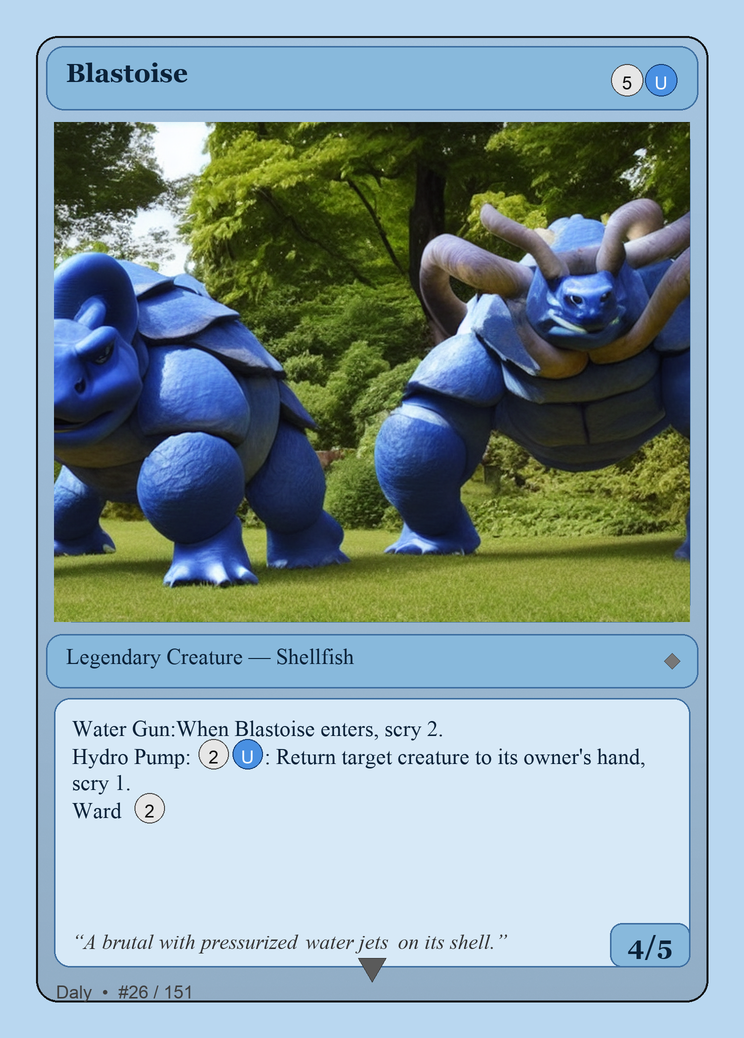

In [73]:
createPokemonMTGCard("Blastoise", pipe, compel)
#fetch_pokemon_features("Starmie")

## Collect Reference Data
It's not necessary to run this every time; just when you want to make sure the data is current

In [20]:
import requests

BASE = POKEAPI + "/pokemon-species?limit=2000"

def _get(url, timeout=15):
    r = requests.get(url, timeout=timeout)
    r.raise_for_status()
    return r.json()


def getPokemonURLs():
    ''' Get all pokemon species as list of dicts w/ keys: 'name', 'url' '''
    url = f"{POKEAPI}/pokemon-species?limit=2000"
    pokemonURLs = requests.get(url, timeout=10).json()["results"]
    return pokemonURLs

